# M5 - Réseau de Neurones (MLP) avec Target Encoding et Optuna

**Objectif** : Entraîner un réseau de neurones (Multi-Layer Perceptron) optimisé sur le dataset Ames Housing pour prédire le prix de vente des maisons.

**Différences clés par rapport à la baseline M0** :
- `LinearRegression` → `MLPRegressor` : passage d'un modèle linéaire simple à un réseau de neurones capable d'apprendre des relations non-linéaires via des couches cachées et des fonctions d'activation.
- **5 variables** → **toutes les variables** + filtre Lasso automatique pour éliminer le bruit.
- **Normalisation renforcée** : le MLP est extrêmement sensible à l'échelle des variables. Un `StandardScaler` est ajouté après le `TargetEncoder` sur les variables catégorielles, en plus du `RobustScaler` sur les numériques. Ce double scaling est absent du M0 et du M3.
- **Architecture dynamique** : Optuna décide automatiquement du nombre de couches (0 à 3) et de neurones par couche (10 à 200), ce qui permet de tester des architectures allant du modèle linéaire au réseau profond.

In [1]:
# M5 - Réseau de Neurones (MLP) + Target Encoding + Optuna Tuning

# 1. IMPORTATIONS POUR LE M5 (Réseau de Neurones)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# Preprocessing classique
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from category_encoders import TargetEncoder
from sklearn.impute import KNNImputer

# Outils pour la sélection de variables et l'optimisation
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import optuna
from optuna.samplers import TPESampler

# Le nouveau modèle : Réseau de Neurones Scikit-Learn
from sklearn.neural_network import MLPRegressor

/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Chargement des Données et Feature Engineering
- On charge `train.csv` et `test.csv`, puis on applique le même feature engineering que le M3 :
    - **Variables combinées** : `TotalSF` (surface totale), `TotalBath` (salles de bain totales), `IsRemodeled` (flag de rénovation).
    - **Encodage ordinal** : Les variables de qualité (`ExterQual`, `KitchenQual`, etc.) sont converties en chiffres de 0 à 5.
    - **Nettoyage des années** : suppression des colonnes brutes remplacées par `AgeBuilt` et `AgeRemod`.
- Suppression des outliers critiques et transformation `log1p` de la cible.
- Séparation en `X_train` / `y_train` / `X_test`.

In [2]:
# 2. CHARGEMENT DES DONNÉES ET PREPARATION DE LA TARGET

def advanced_feature_engineering(data):
    """
    Applique les transformations métiers sur le jeu de données.
    Note : L'encodage ordinal et les variables combinées (TotalSF, TotalBath, IsRemodeled)
    sont inspirés de stratégies performantes trouvées sur les notebooks publics de Kaggle.
    """
    df = data.copy()

    # --- A. CRÉATION DE VARIABLES (Inspiration Kaggle) ---
    # 1. Surface totale (Sous-sol + RDC + 1er étage)
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

    # 2. Salles de bain totales (Les "HalfBath" comptent pour 0.5)
    df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']

    # 3. Rénovation (Flag binaire : 1 si rénové, 0 sinon)
    df['IsRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

    # --- B. ENCODAGE ORDINAL (Inspiration Kaggle) ---
    # On force la qualité en chiffres pour créer une hiérarchie stricte pour le Random Forest
    ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                    'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
    quality_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0, np.nan: 0}

    for col in ordinal_cols:
        if col in df.columns:
            df[col] = df[col].map(quality_map)

    # --- C. GESTION DES DATES (Calcul des âges) ---
    df['AgeBuilt'] = df['YrSold'] - df['YearBuilt']
    df['AgeRemodAdd'] = df['YrSold'] - df['YearRemodAdd']
    df['AgeGarage'] = df['YrSold'] - df['GarageYrBlt']

    # On supprime les anciennes dates brutes qui perturbent le modèle
    df = df.drop(['YearBuilt', 'YearRemodAdd', 'GarageYrBlt'], axis=1)

    return df


# --- 1. Chargement brut ---
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# --- 2. Nettoyage des Outliers (SUR LE TRAIN UNIQUEMENT) ---
# Suppression des 2 transactions aberrantes repérées visuellement (>4000 sqft & <300000$)
train_df = train_df.drop(train_df[train_df['GrLivArea'] > 4000].index)

# --- 3. Feature Engineering ---
train_df = advanced_feature_engineering(train_df)
test_df = advanced_feature_engineering(test_df)

# --- 4. Séparation X et y ---
X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
y_train = pd.Series(np.log1p(train_df['SalePrice']), index=train_df.index)

X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

# 3. Création du Preprocessor (Optimisé pour le Réseau de Neurones)
- Le preprocessing reprend la même base que le M3 (KNNImputer + TargetEncoder), mais avec une adaptation cruciale pour les réseaux de neurones :
    - **`StandardScaler` ajouté sur les variables catégorielles encodées** : après le Target Encoding, les catégories sont remplacées par des prix moyens (ex: 180 000 pour un quartier cher, 120 000 pour un quartier modeste). Ces valeurs sont sur une échelle très différente des variables numériques (0-10 pour OverallQual). Sans normalisation, le MLP accorderait un poids disproportionné aux variables à grande échelle.
    - Dans le M3 (Random Forest), cette normalisation n'était pas nécessaire car les arbres de décision sont insensibles à l'échelle des variables.

In [3]:
# 3. CRÉATION DU PREPROCESSOR (Optimisé pour Réseau de Neurones)

# Redétection dynamique des colonnes après les changements de l'étape 2
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# 1. Identification des "faux manquants"
cat_none_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                     'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                     'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                     'BsmtFinType2', 'MasVnrType']

# Les autres catégorielles
cat_freq_features = [col for col in categorical_features if col not in cat_none_features]

# 2. Pipeline Numérique : Imputation + Scaling (Inchangé)
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', RobustScaler())
])

# 3. Pipeline Catégorielle 1 : Imputation + Encodage + NOUVEAU SCALING
cat_none_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value')),
    ('scaler', StandardScaler()) # <-- Le bouclier indispensable pour le MLP
])

# 4. Pipeline Catégorielle 2 : Imputation + Encodage + NOUVEAU SCALING
cat_freq_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target_encoder', TargetEncoder(smoothing=10, handle_unknown='value', handle_missing='value')),
    ('scaler', StandardScaler()) # <-- Le bouclier indispensable pour le MLP
])

# 5. L'assembleur final (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_none', cat_none_transformer, cat_none_features),
        ('cat_freq', cat_freq_transformer, cat_freq_features)
    ])

# 4. Diagnostic du Preprocessing
- On vérifie la cardinalité des variables catégorielles et le bon fonctionnement du preprocessing.
- Le diagnostic confirme les deux étapes clés pour le MLP : le Target Encoding traduit les catégories en prix moyen, puis le StandardScaler normalise ces valeurs pour que le réseau de neurones converge correctement.

In [4]:
# 3bis. DIAGNOSTIC DU PREPROCESSING
# Affichage des colonnes catégorielles et vérification du preprocessing

print("=" * 60)
print("DIAGNOSTIC DU PREPROCESSING (Target Encoding + Scaling)")
print("=" * 60)
print(f"\n📊 Variables numériques : {len(numeric_features)}")
print(f"   {list(numeric_features)[:5]}... (affichage tronqué)\n")

print(f"📂 Variables catégorielles : {len(categorical_features)}")
for col in categorical_features:
    card = X_train[col].nunique()
    print(f"   {col:20} → cardinalité: {card:3} (top: {X_train[col].value_counts().index[0]})")

print(f"\n✔️  ÉTAPE 1 : Target Encoding va traduire chaque catégorie en prix moyen")
print(f"✔️  ÉTAPE 2 : StandardScaler va normaliser ces prix pour protéger le Réseau de Neurones")
print("=" * 60)

DIAGNOSTIC DU PREPROCESSING (Target Encoding + Scaling)

📊 Variables numériques : 48
   ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond']... (affichage tronqué)

📂 Variables catégorielles : 34
   MSZoning             → cardinalité:   5 (top: RL)
   Street               → cardinalité:   2 (top: Pave)
   Alley                → cardinalité:   2 (top: Grvl)
   LotShape             → cardinalité:   4 (top: Reg)
   LandContour          → cardinalité:   4 (top: Lvl)
   Utilities            → cardinalité:   2 (top: AllPub)
   LotConfig            → cardinalité:   5 (top: Inside)
   LandSlope            → cardinalité:   3 (top: Gtl)
   Neighborhood         → cardinalité:  25 (top: NAmes)
   Condition1           → cardinalité:   9 (top: Norm)
   Condition2           → cardinalité:   8 (top: Norm)
   BldgType             → cardinalité:   5 (top: 1Fam)
   HouseStyle           → cardinalité:   8 (top: 1Story)
   RoofStyle            → cardinalité:   6 (top: Gable)
   RoofMatl  

# 5. Construction de la Pipeline Hybride et Tuning Optuna
- La pipeline M5 suit la même architecture que le M3 :
    1. **Preprocessor** : le `ColumnTransformer` (KNNImputer + TargetEncoder + StandardScaler).
    2. **Filtre Lasso** (`SelectFromModel` + `LassoCV`) : élimination automatique des variables inutiles.
    3. **MLPRegressor** : le réseau de neurones (Multi-Layer Perceptron).
- L'originalité du M5 est que **Optuna choisit l'architecture du réseau** :
    - Nombre de couches cachées (de 0 à 3). Avec 0 couche, le MLP se réduit à un modèle linéaire (neurone unique).
    - Nombre de neurones par couche (de 10 à 200, par pas de 10).
    - Fonction d'activation (`relu` ou `tanh`), taux de régularisation (`alpha`), et learning rate.
- Cela permet de tester automatiquement des architectures très différentes, du modèle linéaire le plus simple au réseau profond, et de trouver le meilleur compromis biais-variance.

In [5]:
# 4. CONSTRUCTION DE LA PIPELINE HYBRIDE ET TUNING (M5 - Réseau de Neurones)

# Étape A : Le Filtre Lasso
feature_selector = SelectFromModel(LassoCV(cv=5, random_state=42))

# Étape B : L'Optimisation avec Optuna (Architecture Dynamique)
def objective(trial):
    """
    Fonction objective pour Optuna : génère dynamiquement le nombre de couches
    et de neurones, teste la combinaison et retourne le RMSE moyen.
    """
    # 1. OPTUNA DÉCIDE DU NOMBRE DE COUCHES (de 0 à 3)
    # 0 couche = Ton idée du neurone unique (Modèle linéaire)
    n_layers = trial.suggest_int('n_layers', 0, 3)

    # 2. OPTUNA DÉCIDE DU NOMBRE DE NEURONES PAR COUCHE
    layers = []
    if n_layers > 0:
        for i in range(n_layers):
            # On teste entre 10 et 200 neurones par couche, par pas de 10
            n_units = trial.suggest_int(f'n_units_layer_{i}', 10, 200, step=10)
            layers.append(n_units)

    hidden_layer_sizes = tuple(layers) # Conversion au format attendu par Sklearn : () ou (X,) ou (X, Y)

    # 3. Autres hyperparamètres classiques
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    solver = trial.suggest_categorical('solver', ['adam'])
    alpha = trial.suggest_float('alpha', 1e-5, 1e-2, log=True)
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)

    # Création du modèle avec l'architecture générée dynamiquement
    mlp_model_trial = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver=solver,
        alpha=alpha,
        learning_rate_init=learning_rate_init,
        max_iter=1000,
        early_stopping=False,
        random_state=42
    )

    pipeline_trial = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('selector', feature_selector),
        ('mlp', mlp_model_trial)
    ])

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline_trial.fit(X_tr, y_tr)
        preds = pipeline_trial.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_scores.append(-rmse)

    return float(np.mean(fold_scores))


# Étape C : Lancement de l'étude Optuna
import time
start_global_time = time.time()
print("Lancement de l'optimisation Optuna pour le Réseau de Neurones...")
print("Recherche dynamique d'architecture de couches complexes...\n")

sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("-" * 50)
print("Optimisation terminée !")
print(f"Meilleur score CV (neg_rmse) : {study.best_value:.4f}")
print(f"Meilleurs hyperparamètres trouvés :\n{study.best_params}")
print("-" * 50)


# Étape D : Réentraîner le meilleur modèle sur tout le jeu de données
best_params = study.best_params

# Reconstitution dynamique du tuple de couches à partir des meilleurs paramètres trouvables
best_layers = []
if best_params['n_layers'] > 0:
    for i in range(best_params['n_layers']):
        best_layers.append(best_params[f'n_units_layer_{i}'])
best_hidden_layer_sizes = tuple(best_layers)

mlp_best = MLPRegressor(
    hidden_layer_sizes=best_hidden_layer_sizes,
    activation=best_params['activation'],
    solver=best_params['solver'],
    alpha=best_params['alpha'],
    learning_rate_init=best_params['learning_rate_init'],
    max_iter=1500,
    early_stopping=False,
    random_state=42
)

best_m5_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('mlp', mlp_best)
])

# Fit final sans encombre
best_m5_pipeline.fit(X_train, y_train)
global_training_time = time.time() - start_global_time

# Évaluation finale sur le Train Set
y_pred_train = best_m5_pipeline.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"Architecture finale retenue : {best_hidden_layer_sizes}")
print(f"RMSE (Log) sur le Train Set avec MLP final : {rmse_train:.4f}")

[I 2026-06-14 14:22:13,358] A new study created in memory with name: no-name-0ce55c9a-b6d3-4c93-8681-6ad23df84bea


Lancement de l'optimisation Optuna pour le Réseau de Neurones...
Recherche dynamique d'architecture de couches complexes...



  0%|          | 0/40 [00:00<?, ?it/s]/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
Best trial: 0. Best value: -2.03048:   2%|▎         | 1/40 [00:09<06:11,  9.52s/it]

[I 2026-06-14 14:22:22,880] Trial 0 finished with value: -2.030478595209109 and parameters: {'n_layers': 1, 'n_units_layer_0': 200, 'activation': 'relu', 'solver': 'adam', 'alpha': 2.9380279387035334e-05, 'learning_rate_init': 0.00020511104188433984}. Best is trial 0 with value: -2.030478595209109.


/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/awalther/anaconda3/envs/dataScience/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
Best trial: 0. Best value: -2.03048:   5%|▌         | 2/40 [00:11<03:22,  5.33s/it]

...

[I 2026-06-14 14:26:27,907] Trial 37 finished with value: -0.8695260226389546 and parameters: {'n_layers': 2, 'n_units_layer_0': 50, 'n_units_layer_1': 110, 'activation': 'tanh', 'solver': 'adam', 'alpha': 2.7409233865259343e-05, 'learning_rate_init': 0.0008582832138634933}. Best is trial 24 with value: -0.22708282744575756.


Best trial: 24. Best value: -0.227083:  98%|█████████▊| 39/40 [04:19<00:05,  5.00s/it]

[I 2026-06-14 14:26:32,387] Trial 38 finished with value: -0.2448796840731808 and parameters: {'n_layers': 3, 'n_units_layer_0': 20, 'n_units_layer_1': 150, 'n_units_layer_2': 180, 'activation': 'tanh', 'solver': 'adam', 'alpha': 3.222171558735319e-05, 'learning_rate_init': 0.0059191809853547045}. Best is trial 24 with value: -0.22708282744575756.


Best trial: 24. Best value: -0.227083: 100%|██████████| 40/40 [04:20<00:00,  6.52s/it]


[I 2026-06-14 14:26:34,262] Trial 39 finished with value: -2.0557699276862462 and parameters: {'n_layers': 3, 'n_units_layer_0': 70, 'n_units_layer_1': 130, 'n_units_layer_2': 90, 'activation': 'relu', 'solver': 'adam', 'alpha': 0.0001672970840090178, 'learning_rate_init': 0.008157240111128646}. Best is trial 24 with value: -0.22708282744575756.
--------------------------------------------------
Optimisation terminée !
Meilleur score CV (neg_rmse) : -0.2271
Meilleurs hyperparamètres trouvés :
{'n_layers': 3, 'n_units_layer_0': 10, 'n_units_layer_1': 150, 'n_units_layer_2': 170, 'activation': 'tanh', 'solver': 'adam', 'alpha': 4.2899743940599205e-05, 'learning_rate_init': 0.002250156272938391}
--------------------------------------------------
Architecture finale retenue : (10, 150, 170)
RMSE (Log) sur le Train Set avec MLP final : 0.1825


# 6. Génération de la Soumission Kaggle
- On utilise le meilleur pipeline trouvé par Optuna pour prédire les prix du jeu de test.
- Les prédictions sont reconverties en dollars avec `expm1`, puis sauvegardées au format CSV Kaggle.

In [6]:
# 5. GÉNÉRATION DE LA SOUMISSION KAGGLE

# On prédit avec le meilleur modèle trouvé
preds_log_m5 = best_m5_pipeline.predict(X_test)
preds_dollars_m5 = np.expm1(preds_log_m5) # Retour au prix en dollars

submission_m5 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_m5
})

fichier_soumission = 'M5_NeuralNetwork_Submission.csv'
submission_m5.to_csv(fichier_soumission, index=False)
print(f"Fichier '{fichier_soumission}' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.")

Fichier 'M5_NeuralNetwork_Submission.csv' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.


# 7. Évaluation Finale : Les 3 Critères du Groupe
- **Mathématique (RMSE)** : Récupéré depuis l'optimisation Optuna (étape 5). C'est le RMSE moyen en validation croisée sur l'échelle logarithmique.
- **IT (Temps d'entraînement)** : Temps d'entraînement global comprenant toute la recherche d'hyperparamètres (l'optimisation Optuna) et le réentraînement final de la meilleure pipeline. Les réseaux de neurones sont généralement plus lents à entraîner.
- **Métier (% d'écart médian)** : Médiane des écarts relatifs entre le prix prédit et le prix réel, en pourcentage.
- **Métier (Écart médian USD)** : Même indicateur exprimé en dollars, pour donner une idée concrète de l'erreur typique en valeur absolue.
- On affiche également le Top 15 des variables les plus importantes par **permutation** : on mélange aléatoirement une colonne et on mesure combien le RMSE augmente. Plus l'augmentation est forte, plus la variable est importante. Cette méthode est indispensable pour les réseaux de neurones qui, contrairement au Random Forest, n'ont pas de `feature_importances_` intégré.

  ÉVALUATION FINALE — MODÈLE M5 RÉSEAU DE NEURONES
  Mathématique (RMSE Log) : 0.22708
  IT (Temps entraînement) : 263.94 secondes
  Métier (Écart médian)   : 11.19 %
  Métier (Écart médian USD): 18,298.55 $

Calcul de l'importance des variables par permutation...


/tmp/ipykernel_10881/3438694006.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Variable', palette='magma')


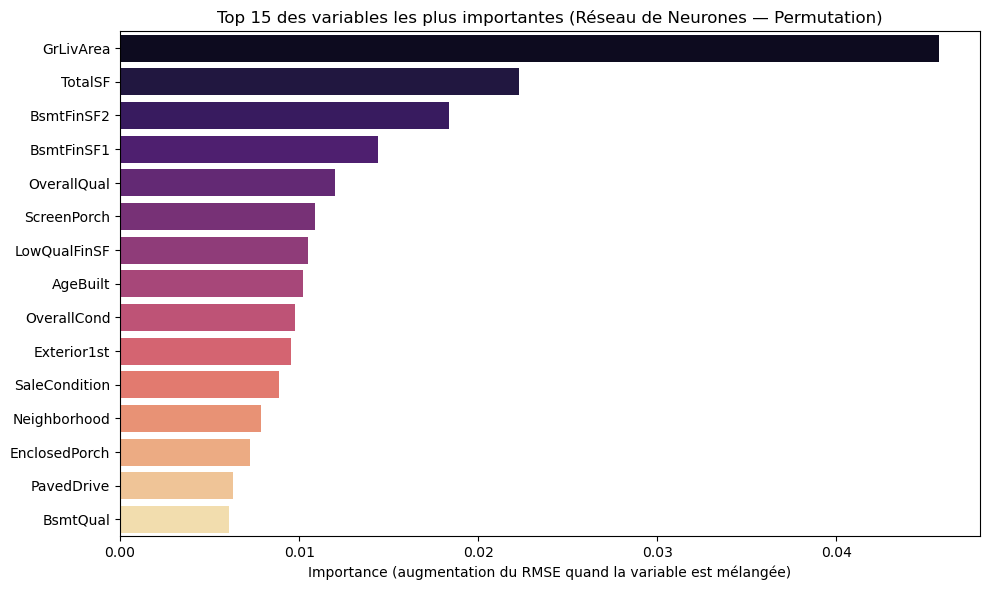

In [7]:
# 7. ÉVALUATION FINALE : LES 3 CRITÈRES DU GROUPE

import time
from sklearn.model_selection import cross_val_predict
from sklearn.inspection import permutation_importance

# ── 1. MATHÉMATIQUE : RMSE (récupéré depuis Optuna, étape 5) ──
rmse_log = -study.best_value  # study.best_value est en neg_rmse

# ── 2. IT : Temps d'entraînement (temps global incluant Optuna et le fit final) ──
train_time = global_training_time

# ── 3. MÉTIER : % d'écart médian (prédictions OOF honnêtes) ──
kf_eval = KFold(n_splits=5, shuffle=True, random_state=42)
oof_pred_log = cross_val_predict(best_m5_pipeline, X_train, y_train, cv=kf_eval, n_jobs=-1)
oof_pred_price = np.expm1(oof_pred_log)
y_train_price = np.expm1(y_train)

ecart_pct = np.abs(oof_pred_price - y_train_price) / y_train_price * 100
ecart_median = np.median(ecart_pct)
ecart_median_usd = np.median(np.abs(oof_pred_price - y_train_price))

# ── AFFICHAGE ──
print("=" * 50)
print("  ÉVALUATION FINALE — MODÈLE M5 RÉSEAU DE NEURONES")
print("=" * 50)
print(f"  Mathématique (RMSE Log) : {rmse_log:.5f}")
print(f"  IT (Temps entraînement) : {train_time:.2f} secondes")
print(f"  Métier (Écart médian)   : {ecart_median:.2f} %")
print(f"  Métier (Écart médian USD): {ecart_median_usd:,.2f} $")
print("=" * 50)

# ── GRAPHE : Importance par Permutation (Top 15) ──
print("\nCalcul de l'importance des variables par permutation...")

result = permutation_importance(
    best_m5_pipeline,
    X_train,
    y_train,
    n_repeats=5,
    random_state=42,
    scoring='neg_root_mean_squared_error'
)

feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Importance': result.importances_mean
})

importance_df = importance_df[importance_df['Importance'] > 0]
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Variable', palette='magma')
plt.title('Top 15 des variables les plus importantes (Réseau de Neurones — Permutation)')
plt.xlabel('Importance (augmentation du RMSE quand la variable est mélangée)')
plt.ylabel('')
plt.tight_layout()
plt.show()